## Appendix: Exploratory Data Analysis (detailed)

This is the project's full screening-stage EDA notebook, the original assignment-level
statistical exploration behind the concise summary in [2. Data Understanding](../02_data_understanding) above.
It's included here in full because most of the project's later modelling decisions (which
macro features survive into Elastic Net, why certain lags are used, why the project treats
forecast-origin availability as an explicit assumption rather than a fact read off the
curated schema) trace back to a specific check somewhere in this notebook.

```{admonition} A dating note
:class: note
Sections 10 and 11 below were originally titled and framed as screening candidate exogenous
features "for SARIMAX." SARIMAX was fully removed from the project on 2026-08-26 (a
root-stability re-selection still validated ~9% worse real walk-forward RMSE than the
reportable models; see the project's model-comparison evidence), and their titles and
prose were updated accordingly. The screening itself wasn't wasted: the same curated macro
table and feature set feed Elastic Net today.
```

Statistical screens throughout are treated as indicative only, since the sample is small and several predictors have early missingness, not as confirmatory hypothesis tests.

Every section here uses quarters up to the forecast origin (2025Q4). Quarters after it are in the
curated table only so the pinned forecasts can be benchmarked against what happened.

In [1]:
from pathlib import Path
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.platform_validation import validate_curated_with_pandera
from src.eda_export import EDA_END_QUARTER, restrict_to_eda_window
from src.transform import latest_dataset_path
from src.validation import validate_curated_dataset

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = ROOT / 'data' / 'curated' / 'quarterly_macro_features.csv'
AVAILABILITY_PATH = ROOT / 'data' / 'metadata' / 'series_availability.csv'
TARGET = 'cpi_yoy'
MAX_LAG = 4
SIGNAL_P_THRESHOLD = 0.10
SIGNAL_CORR_THRESHOLD = 0.20
MATERIAL_MISSING_THRESHOLD = 0.20
VIF_THRESHOLD = 10.0
CPI_FAMILY_BASE_COLS = [
    'cpi_qoq',
    'cpi_yoy',
    'trimmed_mean_cpi_qoq',
    'trimmed_mean_cpi_yoy',
]
CPI_DERIVED_DIAGNOSTIC_COLS = ['headline_trimmed_mean_yoy_gap']
CPI_DIAGNOSTIC_BASE_COLS = [
    'cpi_qoq',
    'trimmed_mean_cpi_qoq',
    'trimmed_mean_cpi_yoy',
    'headline_trimmed_mean_yoy_gap',
]
CPI_FAMILY_LAGGED_FEATURES = [
    'cpi_yoy_lag1',
    'cpi_yoy_lag4',
    'trimmed_mean_cpi_yoy_lag1',
    'trimmed_mean_cpi_yoy_lag4',
]

# House style for the figures that replace the earlier tables (same palette as the main chapters).
INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6"
BLUE, MUTED, ALERT = "#5b6f8f", "#9aa79f", "#c0392b"
BOOK_STYLE = {
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK, "font.size": 10, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
}

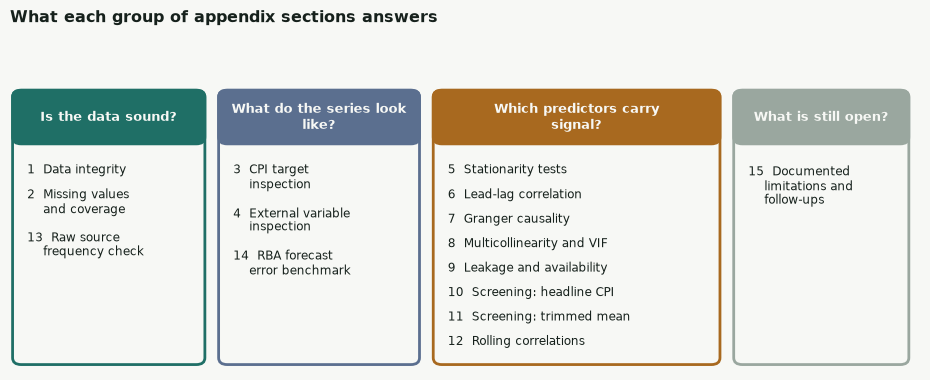

In [ ]:
import textwrap
from matplotlib.patches import FancyBboxPatch

groups = [
    ("Is the data sound?", ACCENT, 2.2, ["1  Data integrity", "2  Missing values and coverage", "13  Raw source frequency check"]),
    ("What do the series look like?", BLUE, 2.3, ["3  CPI target inspection", "4  External variable inspection", "14  RBA forecast error benchmark"]),
    ("Which predictors carry signal?", HIGHLIGHT, 3.3, ["5  Stationarity tests", "6  Lead-lag correlation", "7  Granger causality",
                                                         "8  Multicollinearity and VIF", "9  Leakage and availability",
                                                         "10  Screening: headline CPI", "11  Screening: trimmed mean",
                                                         "12  Rolling correlations"]),
    ("What is still open?", MUTED, 2.0, ["15  Documented limitations and follow-ups"]),
]
with plt.rc_context(BOOK_STYLE):
    fig, ax = plt.subplots(figsize=(9.4, 3.9))
    ax.set_xlim(0, 10.6)
    ax.set_ylim(0, 5)
    ax.axis("off")
    x = 0.05
    for title, colour, width, items in groups:
        ax.add_patch(FancyBboxPatch((x, 0.1), width, 4.0, boxstyle="round,pad=0.02,rounding_size=0.1", facecolor=PAPER,
                                    edgecolor=colour, linewidth=2.0))
        ax.add_patch(FancyBboxPatch((x, 3.35), width, 0.75, boxstyle="round,pad=0.02,rounding_size=0.1", facecolor=colour,
                                    edgecolor=colour, linewidth=2.0))
        ax.text(x + width / 2, 3.72, textwrap.fill(title, 24), ha="center", va="center", fontsize=9.6, fontweight="bold", color=PAPER)
        y = 3.05
        for item in items:
            wrapped = textwrap.fill(item, int(width * 9.5), subsequent_indent="    ")
            ax.text(x + 0.15, y, wrapped, ha="left", va="top", fontsize=8.6, linespacing=1.25)
            y -= 0.26 * (wrapped.count(chr(10)) + 1) + 0.1
        x += width + 0.2
    ax.set_title("What each group of appendix sections answers", loc="left", fontsize=11.5, fontweight="bold")
    fig.tight_layout()
    plt.show()

*Source: `notebooks/EDA.ipynb`. The section numbers here follow the page order, while the notebook itself labels pages 11, 12, 13 and 15 as 10b, 11, 12 and 13.*